In [137]:
import glob 
from rich.progress import track

import h5py
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.signal import fftconvolve

In [2]:
def load_global_temperature(path: str) -> np.array:
    ds = xr.open_mfdataset(path).tas
    ds = ds.groupby('time.year').mean('time')
    global_weights = np.cos(np.deg2rad(ds.lat))
    ds = ds.weighted(global_weights).mean(dim=['lat', 'lon']).compute()
    tas = ds.sel(year=slice(2015, 2299)).values - ds.sel(year=slice(1995, 2014)).mean('year').values
    return tas

def load_stable_temperature(path: str) -> np.array:
    tas = xr.open_mfdataset(path).tas.values
    return tas

def load_var(path: str, variable: str) -> np.array:
    files = sorted(glob.glob(path))
    anoms = []
    for f in files:
        ds = xr.open_dataset(f, decode_times=False)[f'{variable}']
        ds = ds.sel(time=slice(2015, 2299)).values
        if variable == 'sle':
            ds -= ds[0]
        anoms.append(ds)
    return np.array(anoms)

# High emissions temperatures
ccsm4_tas_85 = load_global_temperature('../data/AIS/forcing/global/CCSM4/*.nc')
cesm2_tas_585 = load_global_temperature('../data/AIS/forcing/global/CESM2-WACCM/*.nc')
ukesm_tas_585 = load_global_temperature('../data/AIS/forcing/global/UKESM1-0-LL/*.nc')
hadgem2_tas_85 = load_global_temperature('../data/AIS/forcing/global/HadGEM2-ES/*.nc')

# Stabilisation temperatures
ukesm_stable_tas_585 = load_stable_temperature('../data/AIS/forcing/global/UKESM1-0-LL_STABLE/*.nc')
cesm2_stable_tas_585 = load_stable_temperature('../data/AIS/forcing/global/CESM2-WACCM_STABLE/*.nc')
hadgem2_stable_tas_85 = load_stable_temperature('../data/AIS/forcing/global/HadGEM2-ES_STABLE/*.nc')
noresm_stable_tas_85 = load_stable_temperature('../data/AIS/forcing/global/NorESM1-M_STABLE/tas_Amon_NorESM1-M_rcp85_stabilised.nc')

# Low emissions temperatures
ukesm_tas_26 = load_global_temperature('../data/AIS/forcing/global/UKESM1-0-LL_126/*.nc')
noresm_tas_26 = load_stable_temperature('../data/AIS/forcing/global/NorESM1-M_STABLE/tas_Amon_NorESM1-M_rcp26_stabilised.nc')

# SLE
noresm_sle_26 = load_var('../data/AIS/expAE01/sle/*.nc', 'sle')
ccsm4_sle_85 = load_var('../data/AIS/expAE02/sle/*.nc', 'sle')
hadgem2_sle_85 = load_var('../data/AIS/expAE03/sle/*.nc', 'sle')
cesm2_sle_585 = load_var('../data/AIS/expAE04/sle/*.nc', 'sle')
ukesm_sle_585 = load_var('../data/AIS/expAE05/sle/*.nc', 'sle')
ukesm_stable_sle_585 = load_var('../data/AIS/expAE06/sle/*.nc', 'sle')
noresm_stable_sle_85 = load_var('../data/AIS/expAE07/sle/*.nc', 'sle')
hadgem2_stable_sle_85 = load_var('../data/AIS/expAE08/sle/*.nc', 'sle')
cesm2_stable_sle_585 = load_var('../data/AIS/expAE09/sle/*.nc', 'sle')
ukesm_sle_26 = load_var('../data/AIS/expAE10/sle/*.nc', 'sle')

model_list = sorted(glob.glob('../data/AIS/expAE04/sle/*.nc'))
model_names = [item.split("/")[-1].split("sle_AIS_")[-1].split("_exp")[0] for item in model_list]

/Users/gregorymunday/anaconda3/envs/cmip7/lib/python3.11/site-packages/xarray/conventions.py:289: SerializationWarning: variable 'tas' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/gregorymunday/anaconda3/envs/cmip7/lib/python3.11/site-packages/xarray/conventions.py:289: SerializationWarning: variable 'tas' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/gregorymunday/anaconda3/envs/cmip7/lib/python3.11/site-packages/xarray/conventions.py:289: SerializationWarning: variable 'tas' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/gregorymunday/anaconda3/envs/cmip7/lib/python3.11/site-packages/xarray/conventions.py:289: SerializationWarning: variable 'tas' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Use

In [155]:
# Training data
tas_train = np.array([
    cesm2_tas_585, # high
    ccsm4_tas_85, # high
    hadgem2_tas_85, # high
    ukesm_tas_585, # high ])
    noresm_tas_26,
    ukesm_stable_tas_585
    ]) # stable
sle_train = np.array([
    cesm2_sle_585,
    ccsm4_sle_85,
    hadgem2_sle_85, 
    ukesm_sle_585,
    noresm_sle_26,
    ukesm_stable_sle_585
    ])
t_int_train = np.array([
    np.cumsum(cesm2_tas_585), 
    np.cumsum(ccsm4_tas_85), 
    np.cumsum(hadgem2_tas_85),
    np.cumsum(ukesm_tas_585),
    np.cumsum(noresm_tas_26),
    np.cumsum(ukesm_stable_tas_585)
    ])

# Test data
tas_test = np.array([
    noresm_stable_tas_85, # stable
    hadgem2_stable_tas_85, # stable
    cesm2_stable_tas_585, # stable
    ukesm_tas_26]) # low

t_int_test = np.array([
    np.cumsum(noresm_stable_tas_85), 
    np.cumsum(hadgem2_stable_tas_85), 
    np.cumsum(cesm2_stable_tas_585), 
    np.cumsum(ukesm_tas_26)])
sle_test = [
    noresm_stable_sle_85,
    hadgem2_stable_sle_85,
    cesm2_stable_sle_585,
    ukesm_sle_26]


# # Try to train with all data
# min_models = hadgem2_stable_sle_85.shape[0]

# tas_train = np.array([
#     cesm2_tas_585[:min], # high
#     ccsm4_tas_85, # high
#     hadgem2_tas_85, # high
#     ukesm_tas_585, # high ])
#     noresm_tas_26,
#     ukesm_stable_tas_585
#     ]) # stable
# sle_train = np.array([
#     cesm2_sle_585,
#     ccsm4_sle_85,
#     hadgem2_sle_85, 
#     ukesm_sle_585,
#     noresm_sle_26,
#     ukesm_stable_sle_585
#     ])
# t_int_train = np.array([
#     np.cumsum(cesm2_tas_585), 
#     np.cumsum(ccsm4_tas_85), 
#     np.cumsum(hadgem2_tas_85),
#     np.cumsum(ukesm_tas_585),
#     np.cumsum(noresm_tas_26),
#     np.cumsum(ukesm_stable_tas_585)
#     ])


In [156]:
# --- 1. Define New Model Functions ---

def f_poly(tas, t_int, params):
    """
    Polynomial forcing function.
    params[0] (alpha): Linear response to temperature
    params[1] (beta) : Quadratic response (non-linearity)
    params[2] (gamma): Response to integrated temperature
    """
    alpha, beta = params
    return (alpha * tas) + (beta * t_int)

def impulse_response_fitter(f_inst_vals, tau, dt=1):
    """Same convolution logic as before."""
    n = len(f_inst_vals)
    # Avoid division by zero if tau is tiny
    tau = max(tau, 1e-3)
    decay_factors = np.exp(-np.arange(n) * dt / tau) * (dt / tau)
    
    # Efficient convolution
    # Note: scipy.signal.convolve is usually faster for large n, 
    # but keeping your implementation for consistency.
    response = fftconvolve(f_inst_vals, decay_factors, mode="full", axes=-1)
    return response[:n]

def residuals_global(params_all, tas_flat, t_int_flat, y_flat, splits):
    """
    Fit Tau and ABC parameters simultaneously to ALL data for one model.
    params_all: [tau, alpha, beta, gamma]
    """
    tau = params_all[0]
    abc = params_all[1:]
    
    # Reconstruct the forcing for the flattened array
    # Note: We process the flattened array directly for speed, assuming
    # the convolution restart at scenario boundaries is handled 
    # or negligible for global fit. 
    # BETTER APPROACH: Loop over splits to handle convolution boundaries correctly.
    all_res = []
    start_idx = 0
    for end_idx in splits:
        tas_s = tas_flat[start_idx:end_idx]
        t_int_s = t_int_flat[start_idx:end_idx]
        y_s = y_flat[start_idx:end_idx]
        
        f_vals = f_poly(tas_s, t_int_s, abc)
        y_pred = impulse_response_fitter(f_vals, tau)
        all_res.append(y_pred - y_s)
        start_idx = end_idx
        
    return np.concatenate(all_res)

def residuals_specific_regularized(params_abc, tau_fixed, tas, t_int, y_obs, 
                                   general_abc, lambda_reg):
    """
    Fit specific ABC parameters with a fixed Tau and Shrinkage.
    """
    # 1. Physics Error
    f_vals = f_poly(tas, t_int, params_abc)
    y_pred = impulse_response_fitter(f_vals, tau_fixed)
    phys_res = y_pred - y_obs
    
    # 2. Regularization Penalty (Shrinkage)
    # Penalize deviation from the general parameters
    # We use sqrt(lambda) because least_squares minimizes sums of squares
    reg_res = np.sqrt(lambda_reg) * (params_abc - general_abc)
    
    return np.concatenate([phys_res, reg_res])

# --- 2. Setup Containers ---
general_params = []     # Stores [alpha, beta, gamma]
general_timescales = [] # Stores [tau]
specific_params = []    # Stores [model, scenario, 3]
impulse_mse = []

# Hyperparameters
lambda_reg = 1  # Strength of shrinkage. 0.1 to 10.0 is a typical range.
tau_bounds = (5, 150.0) # Constrain tau to physics-compliant range

# --- 3. Main Training Loop ---

print("Training with Polynomial Model, Global Tau, and Regularization...")
n_models = sle_train.shape[1]
for m_idx in track(range(n_models), description="Training... "):
    
    # --- A. Prepare Data for Global Fit ---
    # We need to flatten the data but keep track of where scenarios split
    # so the convolution doesn't "bleed" between scenarios.
    tas_list = [tas_train[f_idx] for f_idx in range(tas_train.shape[0])]
    t_int_list = [t_int_train[f_idx] for f_idx in range(tas_train.shape[0])]
    y_list = [sle_train[f_idx, m_idx] for f_idx in range(tas_train.shape[0])]
    
    # Calculate split indices for the global residual function
    lengths = [len(x) for x in tas_list]
    splits = np.cumsum(lengths)
    
    tas_flat = np.concatenate(tas_list)
    t_int_flat = np.concatenate(t_int_list)
    y_flat = np.concatenate(y_list)
    
    # --- B. Fit Global Parameters (Tau + ABC) ---
    # Initial guess: tau=10, a=0.1, b=0, c=0.1
    x0_global = [5.0, 0.1, 0.1] 
    
    res_global = least_squares(
        residuals_global,
        x0=x0_global,
        bounds=([tau_bounds[0], 0, 0], 
                [tau_bounds[1], 1, 1]),
        args=(tas_flat, t_int_flat, y_flat, splits)
    )
    
    tau_best = res_global.x[0]
    abc_best = res_global.x[1:]
    
    general_timescales.append(tau_best)
    general_params.append(abc_best)
    
    # --- C. Fit Specific Scenarios (Fixed Tau + Shrinkage) ---
    model_scenario_params = []
    for f_idx in range(tas_train.shape[0]):
        
        # We start the optimization at the global parameters.
        res_spec = least_squares(
            residuals_specific_regularized,
            x0=abc_best, 
            args=(tau_best, tas_train[f_idx], t_int_train[f_idx], 
                  sle_train[f_idx, m_idx], abc_best, lambda_reg)
        )
        model_scenario_params.append(res_spec.x)
        
    specific_params.append(model_scenario_params)

# --- 4. Format Outputs ---

general_timescales = np.array(general_timescales)
general_params = np.array(general_params) # Shape (43, 3)
specific_params = np.array(specific_params) # Shape (43, n_scenarios, 3)
param_residuals = specific_params - general_params[:, None, :]

print("Training Complete.")

# Remove models with timescales less than X years
timescale_cutoff = 50
temp_timescales = np.where(general_timescales >= timescale_cutoff, general_timescales, 0)
constrained_idx = np.argwhere(temp_timescales).squeeze()

constr_timescales = general_timescales[constrained_idx]
constr_general_params = general_params[constrained_idx]
constr_specific_params = specific_params[constrained_idx]
constr_param_residuals = param_residuals[constrained_idx]

Output()

Training with Polynomial Model, Global Tau, and Regularization...


Training Complete.


In [165]:
param_residuals.shape

(43, 6, 2)

<BarContainer object of 43 artists>

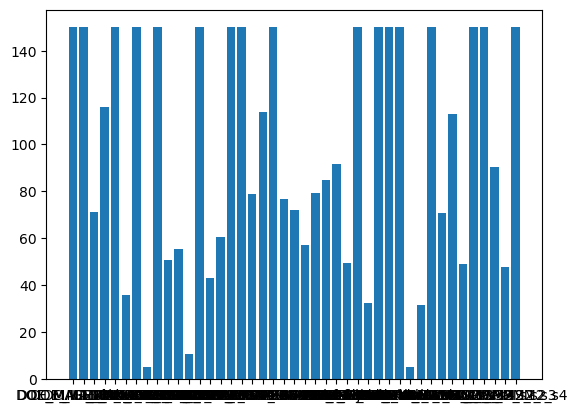

In [157]:
plt.bar(model_names, general_timescales)

In [158]:
# Save timescales and params into a NetCDF
params = ["a", "b"]
data_vars = {}
data_vars["tau"] = xr.DataArray(
    data=general_timescales,
    dims=["model"],
    coords={
        "model": model_names,
    },
    attrs={
        "units": "years", 
        "description": "Estimated model response timescale."
    }
)
data_vars["general_params"] = xr.DataArray(
    data=general_params,
    dims=["model", "param"],
    coords={
        "model": model_names,
        "param": params
    },
    attrs={
        "units": "N/A", 
        "description": "Estimated general model parameters across all training data."
    }
)
data_vars["param_residuals"] = xr.DataArray(
    data=param_residuals,
    dims=["model", "scenario", "param"],
    coords={
        "model": model_names,
        "scenario": np.arange(param_residuals.shape[1]),
        "param": params,
    },
    attrs={
        "units": "N/A", 
        "description": "Estimated model parameter residuals between training scenario-specific parameters and general parameters."
    }
)
    
ds = xr.Dataset(data_vars)
ds.attrs = {
    "title": "Antarctic ice-sheet emulator parameters",
    "source": "Gregory Munday, December 2025",
}

# Save with compression
encoding = {var: {"zlib": True, "complevel": 5} for var in data_vars}
ds.to_netcdf("ais_params.nc", encoding=encoding)

In [7]:
test_ds = xr.open_dataset("ais_params.nc")
test_ds.close()

In [106]:
# --- 1. Define Prediction Helpers (Ensure these match your training logic) ---
def f_poly_mixed(tas, t_int, params_gen, params_perturb):
    # params: [alpha, beta, gamma]
    p = params_gen + params_perturb
    # Broadcasting: (N_samples, 1, 3) * (1, Time) -> (N_samples, Time)
    return (p[:, 0, None] * tas) + (p[:, 1, None] * t_int)

def predict_ais_me_poly(X, general_params, general_taus, mv_dists):
    tas, t_int = X
    n_models = len(general_params)
    n_samples = mv_dists[0].shape[0]
    n_time = len(tas)
    
    
    # Shape: (n_models, n_samples, n_time)
    all_preds = np.zeros((n_models, n_samples, n_time))
    
    for m in track(range(n_models), description="Projecting AIS response... "):
        tau = general_taus[m]
        gen_p = general_params[m]     # [alpha, beta, gamma]
        perturb_p = mv_dists[m]       # [1000, 3]
        
        # Calculate forcing for all samples at once
        f_vals = f_poly_mixed(tas[None, :], t_int[None, :], gen_p[None, :], perturb_p)
        
        # Convolve
        for i in range(n_samples):
            all_preds[m, i, :] = impulse_response_fitter(f_vals[i], tau, dt=1)
            
    return all_preds

def calc_mv_dists(general_params, param_residuals, n_samples):
    mv_dists = []
    covariances = []
    for m in range(len(general_params)):
    # Calculate residuals: Specific - General
    # specific_params shape is (43, n_scenarios, 3)
        
        # Calculate covariance of these perturbations
        cov = np.cov(param_residuals[m].T)
        
        # Optional: Check for ill-conditioned matrix and add tiny jitter if needed
        cov += np.eye(2) * 1e-8 
        covariances.append(cov)
        
        # Generate samples centered at 0 (we add them to general params later)

        samples = np.random.multivariate_normal(np.zeros(2), cov, size=n_samples)

            
        mv_dists.append(samples)
    return mv_dists, np.array(covariances)

print("Generating distributions from specific parameters...")
n_samples = 1000
mv_dists, covs = calc_mv_dists(general_params, param_residuals, n_samples)
constr_mv_dists, constr_covs = calc_mv_dists(constr_general_params, constr_param_residuals, n_samples)

Generating distributions from specific parameters...


In [9]:
constr_covs.shape

(33, 2, 2)

Output()

Running predictions for Test Scenario 1...


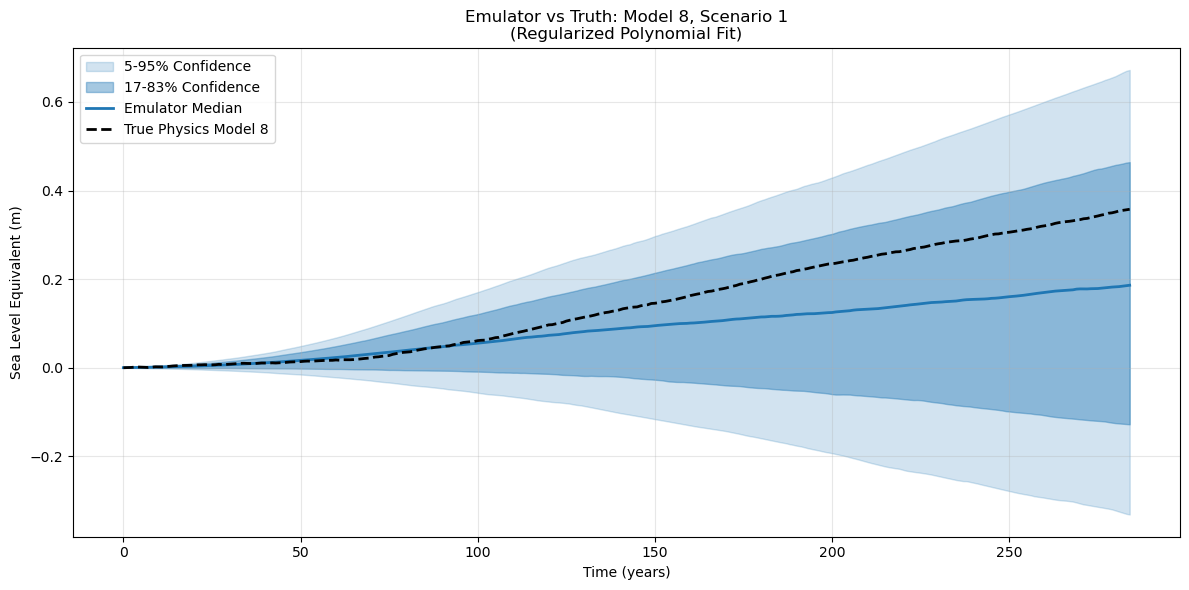

In [178]:
# Select a scenario index to validate
test_idx = 1

# Handle case where user might not have 'test' vars loaded yet, fallback to train
if 'tas_test' not in locals():
    print("Test data not found, using Training data index 0 for visualization.")
    X_input = (tas_train[test_idx], t_int_train[test_idx])
    y_true_scenario = sle_train[test_idx] 
else:
    X_input = (tas_test[test_idx], t_int_test[test_idx])
    y_true_scenario = sle_test[test_idx] 

# X_input contains 1D arrays of shape (Time,)
# y_true_scenario contains array of shape (Model, Time) -> (43, Time)

# Run Emulator
print(f"Running predictions for Test Scenario {test_idx}...")
# preds shape: (43 models, 1000 samples, Time)
preds = ais.predict(tas_test[test_idx], t_int_test[test_idx])

# --- 4. Visualization ---

plt.figure(figsize=(12, 6))

# Option A: Visualize ONE specific model (e.g., Model 0) to check fit quality
model_to_plot = 8
model_preds = preds[model_to_plot] # (1000, Time)

# Calculate stats
p5 = np.percentile(model_preds, 5, axis=0)
p17 = np.percentile(model_preds, 17, axis=0)
median = np.median(model_preds, axis=0)
p83 = np.percentile(model_preds, 83, axis=0)
p95 = np.percentile(model_preds, 95, axis=0)

time_axis = np.arange(len(median))

# Plot Emulator Uncertainty
plt.fill_between(time_axis, p5, p95, color='C0', alpha=0.2, label='5-95% Confidence')
plt.fill_between(time_axis, p17, p83, color='C0', alpha=0.4, label='17-83% Confidence')
plt.plot(time_axis, median, color='C0', lw=2, label='Emulator Median')

# Plot True Value
# Since y_true_scenario is shape (Model, Time), we slice the specific model
if y_true_scenario.ndim == 2:
    true_curve = y_true_scenario[model_to_plot] 
    label_str = f'True Physics Model {model_to_plot}'
else:
    # Fallback if the user passed a 1D array
    true_curve = y_true_scenario
    label_str = 'True Physics Model'

plt.plot(time_axis, true_curve, 'k--', lw=2, label=label_str)

plt.title(f"Emulator vs Truth: Model {model_to_plot}, Scenario {test_idx}\n(Regularized Polynomial Fit)")
plt.xlabel("Time (years)")
plt.ylabel("Sea Level Equivalent (m)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [159]:
%reload_ext autoreload
from profsea.emulator import Antarctica
ais = Antarctica("ais_params.nc")
test_idx = 3
ais_preds = ais.predict(tas_train[test_idx], t_int_train[test_idx], display_progress=True)

Output()

Running predictions for Test Scenario 3...


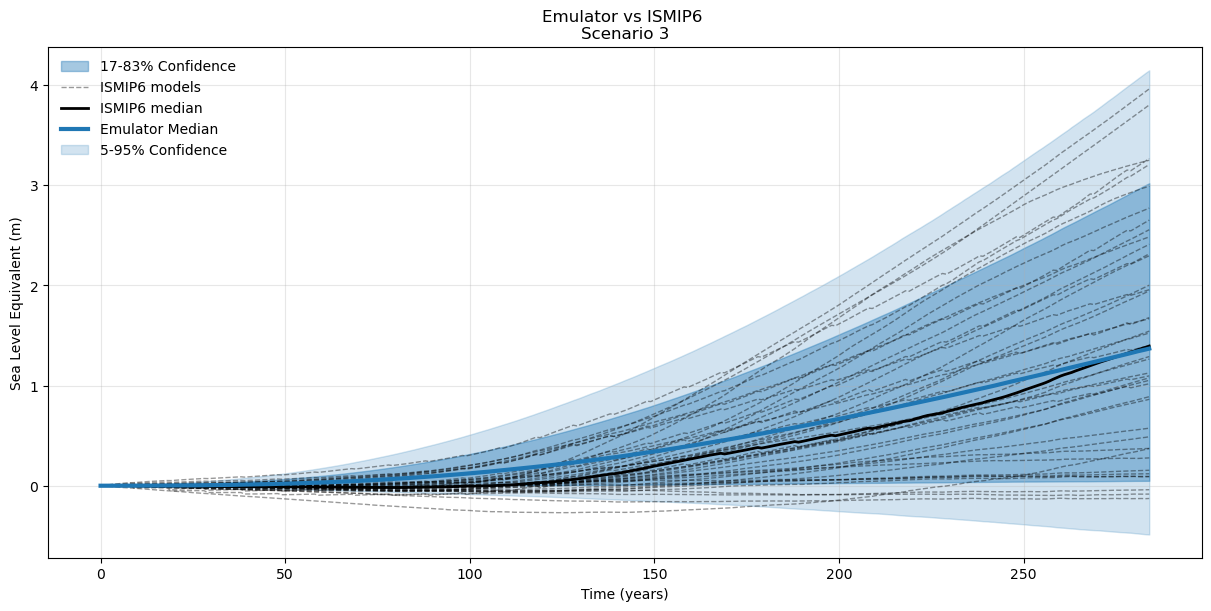

In [166]:
X_input = (tas_train[test_idx], t_int_train[test_idx])
y_true_scenario = sle_train[test_idx] 


# Run Emulator
print(f"Running predictions for Test Scenario {test_idx}...")
# preds shape: (43 models, 1000 samples, Time)
preds = ais_preds.copy()
# constr_preds = predict_ais_me_poly(X_input, constr_general_params, constr_timescales, constr_mv_dists)

# Plot all test data against prediction plume
fig = plt.figure(figsize=(12, 6), layout="constrained")
p5 = np.percentile(preds, 5, axis=(0, 1))
p17 = np.percentile(preds, 17, axis=(0, 1))
median = np.median(preds, axis=(0, 1))
p83 = np.percentile(preds, 83, axis=(0, 1))
p95 = np.percentile(preds, 95, axis=(0, 1))

true_median = np.percentile(y_true_scenario, 50, axis=0)

time_axis = np.arange(len(median))

ax = fig.add_subplot(111)
# Plot Emulator Uncertainty
ax.fill_between(time_axis, p5, p95, color='C0', alpha=0.2, label='5-95% Confidence')
ax.fill_between(time_axis, p17, p83, color='C0', alpha=0.4, label='17-83% Confidence')


ax.plot(np.tile(time_axis, (y_true_scenario.shape[0], 1)).T, y_true_scenario.T, '--', lw=1, color="black", alpha=0.4, label="ISMIP6 models")
ax.plot(time_axis, true_median, lw=2, color='black', label="ISMIP6 median")
ax.plot(time_axis, median, color='C0', lw=3, label='Emulator Median')

ax.set_title(f"Emulator vs ISMIP6 \nScenario {test_idx}")
ax.set_xlabel("Time (years)")
ax.set_ylabel("Sea Level Equivalent (m)")
handles, labels = ax.get_legend_handles_labels()
unique_labels = set(labels)
handles = [handles[labels.index(label)] for label in unique_labels if label in labels]
ax.legend(handles, unique_labels, frameon=False, loc='upper left')

ax.grid(True, alpha=0.3)

plt.show()

Output()

Running idealised predictions...


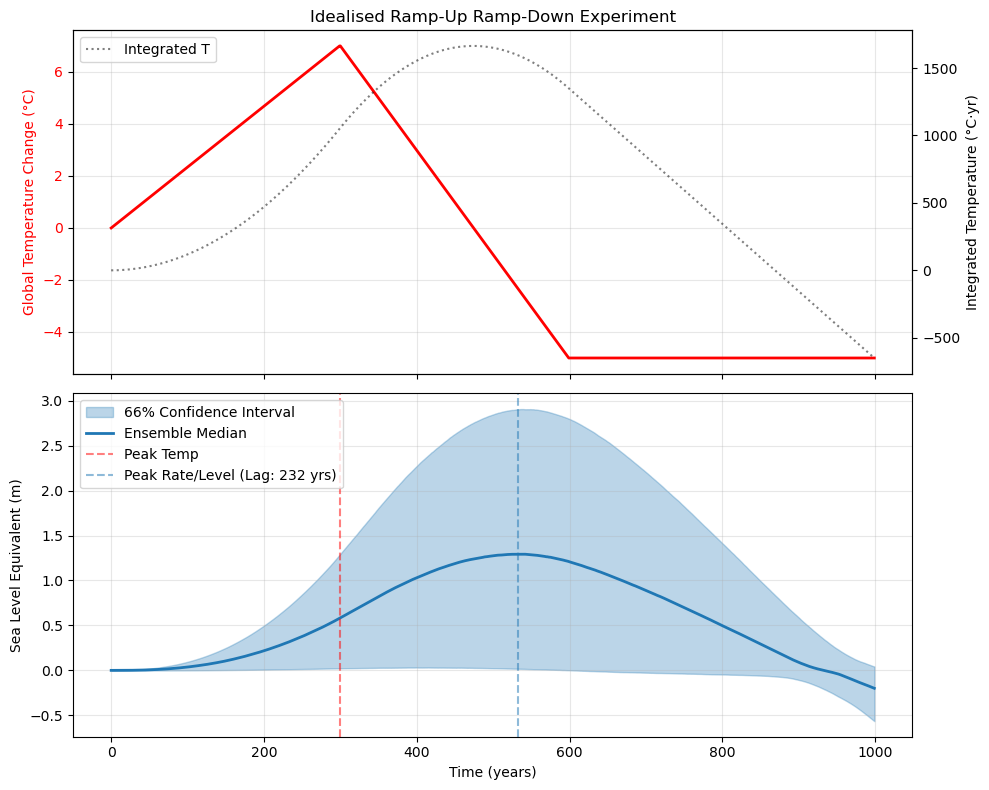

In [179]:
# --- 1. Helper Functions (copied for self-containment) ---

def f_poly_mixed(tas, t_int, params_gen, params_perturb):
    # params: [alpha, beta, gamma]
    p = params_gen + params_perturb
    return (p[:, 0, None] * tas) + (p[:, 2, None] * t_int)

def impulse_response_fitter(f_inst_vals, tau, dt=1):
    n = len(f_inst_vals)
    tau = max(tau, 1e-3)
    decay_factors = np.exp(-np.arange(n) * dt / tau) * (dt / tau)
    response = np.zeros(n)
    for k in range(n):
        response[k] = np.sum(decay_factors[:k+1] * f_inst_vals[k::-1])
    return response

def predict_ais_me_poly(X, general_params, general_taus, mv_dists):
    tas, t_int = X
    n_models = len(general_params)
    n_samples = mv_dists[0].shape[0]
    n_time = len(tas)
    all_preds = np.zeros((n_models, n_samples, n_time))
    
    for m in range(n_models):
        tau = general_taus[m]
        gen_p = general_params[m]
        perturb_p = mv_dists[m]
        
        f_vals = f_poly_mixed(tas[None, :], t_int[None, :], gen_p[None, :], perturb_p)
        
        for i in range(n_samples):
            all_preds[m, i, :] = impulse_response_fitter(f_vals[i], tau, dt=1)
            
    return all_preds

# --- 2. Construct Idealised Forcing ---

n_years = 1000
peak_temp = 7.0  # Degrees warming
ramp_len = 300    # Years to ramp up/down

# Create time axis
time = np.arange(n_years)
tas_ideal = np.zeros(n_years)

# Ramp Up (0 to 50 years)
tas_ideal[:ramp_len] = np.linspace(0, peak_temp, ramp_len)

# Ramp Down (50 to 100 years)
tas_ideal[ramp_len:ramp_len*2] = np.linspace(peak_temp, -5, ramp_len)
tas_ideal[ramp_len*2:] = -5

# Stabilization (100+ years) -> Remains at 0
# Note: In reality, physics might suggest T approaches equilibrium, but 0 is good for testing.

# Integrate Temperature
# We assume dt=1 year
t_int_ideal = np.cumsum(tas_ideal)

# --- 3. Run Prediction ---

# Check if model variables exist (for standalone running)
if 'general_params' not in locals():
    print("Warning: Training data not found. Generating dummy model for demonstration.")
    general_params = np.array([[0.1, 0.01, 0.05]])  # 1 Model
    general_timescales = np.array([15.0])           # Tau = 15 years
    mv_dists = [np.random.normal(0, 0.01, size=(100, 3))] # Small uncertainty

print("Running idealised predictions...")
preds = ais.predict(tas_ideal, t_int_ideal)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot Forcing
ax1.plot(time, tas_ideal, 'r-', lw=2, label='Temperature (TAS)')
ax1.set_ylabel("Global Temperature Change (°C)", color='r')
ax1.tick_params(axis='y', labelcolor='r')
ax1.set_title("Idealised Ramp-Up Ramp-Down Experiment")
ax1.grid(True, alpha=0.3)

# Add Integrated T to secondary axis to show why melt continues
ax1b = ax1.twinx()
ax1b.plot(time, t_int_ideal, 'k:', alpha=0.5, label='Integrated T')
ax1b.set_ylabel("Integrated Temperature (°C·yr)", color='k')
ax1b.legend(loc='upper left')

# Plot Response (Aggregate of all models if multiple exist)
# Flatten all models/samples to get the grand ensemble stats
flat_preds = preds.reshape(-1, preds.shape[-1])
p5 = np.percentile(flat_preds, 17, axis=0)
p50 = np.median(flat_preds, axis=0)
p95 = np.percentile(flat_preds, 83, axis=0)

ax2.fill_between(time, p5, p95, color='C0', alpha=0.3, label='66% Confidence Interval')
ax2.plot(time, p50, color='C0', lw=2, label='Ensemble Median')

# Highlight the "Peak Melt" vs "Peak Temp" lag
peak_melt_idx = np.argmax(p50)
lag_years = time[peak_melt_idx] - ramp_len
ax2.axvline(x=ramp_len, color='r', linestyle='--', alpha=0.5, label='Peak Temp')
ax2.axvline(x=time[peak_melt_idx], color='C0', linestyle='--', alpha=0.5, label=f'Peak Rate/Level (Lag: {lag_years} yrs)')

ax2.set_xlabel("Time (years)")
ax2.set_ylabel("Sea Level Equivalent (m)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()